
# Predicting Basketball Player Styles Using Regular Season Data


## **Definition of the Problem**

Basketball players have different ways of playing, usually grouped into three types: offensive, defensive, and balanced. Offensive players focus on scoring points and helping their team on offense. Defensive players work on stopping the other team from scoring and disrupting their plays. Balanced players do a mix of both, helping with scoring and defense.

As a basketball fan and researcher, I’m interested in how we can use performance stats from regular-season games to figure out a player’s style of play. This project aims to make it easier to classify players into these three groups based on their stats. The results can help coaches make better decisions and improve team strategies.

## **Data Acquisition**

The datasets used for this project include the following:

1. **Regular Season Box Scores (2010–2024):** This dataset contains detailed player statistics for regular season games and was sourced from a GitHub repository. The repository appears to have collected the data through web scraping and is updated twice a year to ensure its accuracy and relevance. A standout feature of this dataset is its completeness—it includes data for all players, whether they played in a particular game or not, and covers every regular season game from 2010 to 2024. This level of detail ensures comprehensive analysis of player performance.

2. **Basketball Players' Styles:** This dataset provides labels that categorize players' playing styles (offensive, defensive, or balanced). These labels were manually gathered through online research, where each player’s style was looked up and categorized based on publicly available information.

Together, these datasets offer a robust foundation for analyzing and classifying basketball players' playing styles using both quantitative game performance data and qualitative style categorization.

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report

from collections import Counter
import warnings
import seaborn as sns


warnings.filterwarnings('ignore')
np.random.seed(42)

### 1. Data Loading and Initial Cleaning

In [192]:
file_paths = [
    "data/regular_season_box_scores_2010_2024_part_1.csv",
    "data/regular_season_box_scores_2010_2024_part_2.csv",
    "data/regular_season_box_scores_2010_2024_part_3.csv",
]

# Concatenate multiple CSVs
regular_season_data = pd.concat(
    [pd.read_csv(file) for file in file_paths],
    ignore_index=True
)

# Filter out rows where there is a comment => means player did not play
regular_season_data = regular_season_data[
    regular_season_data['comment'].isna()
]

# Load styles data and merge
styles_data = pd.read_csv("data/basketball_players_styles.csv")
regular_season_data = pd.merge(
    regular_season_data,
    styles_data[['Player', 'Style']],
    left_on='personName',
    right_on='Player',
    how='left'
)

# Map style to numeric labels
style_mapping = {'Offensive': 0, 'Defensive': 1, 'Balanced': 2}
regular_season_data['style_label'] = regular_season_data['Style'].map(style_mapping)

# Drop rows with missing labels
regular_season_data.dropna(subset=['style_label'], inplace=True)

# Convert labels to int
regular_season_data['style_label'] = regular_season_data['style_label'].astype(int)

print(f"Number of all data (row-level): {len(regular_season_data)}")

Number of all data (row-level): 345889


### **Exploration and Analysis of Data**

### Understanding the Dataset:
- **Regular Season Data** contains performance metrics like points, assists, rebounds, and shooting percentages.
- **Styles Data** maps players to playing styles: Offensive, Defensive, and Balanced.

### Feature Engineering:
- **True Shooting Percentage (TS%)**: A measure of a player's shooting efficiency, calculated as Points / [2 * (FGA + 0.44 * FTA)].
- **Minutes Played**: Converted from time strings to float minutes.



In [193]:
def time_to_float(time_str):
    """Converts a time string 'MM:SS' to float minutes."""
    try:
        minutes, seconds = map(int, time_str.split(':'))
        return minutes + seconds / 60
    except (ValueError, AttributeError):
        return 0.0

def add_true_shooting_percentage(df):
    df['minutes'] = df['minutes'].apply(time_to_float).fillna(0)
    
    # True Shooting% = Points / [2 * (FGA + 0.44 * FTA)]
    df['TS%'] = 0.0
    mask = (df['fieldGoalsAttempted'] + 0.44 * df['freeThrowsAttempted']) != 0
    df.loc[mask, 'TS%'] = (
        df.loc[mask, 'points'] /
        (2 * (df.loc[mask, 'fieldGoalsAttempted']
              + 0.44 * df.loc[mask, 'freeThrowsAttempted']))
    )
    return df

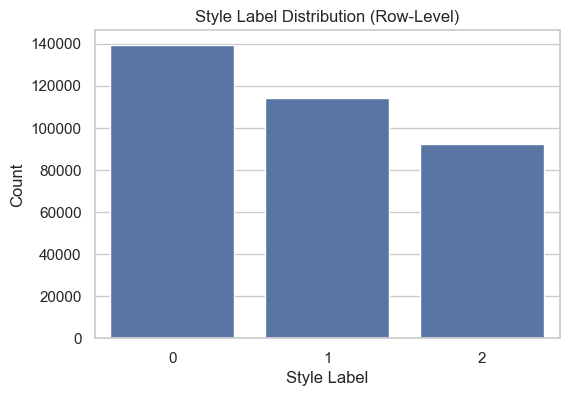

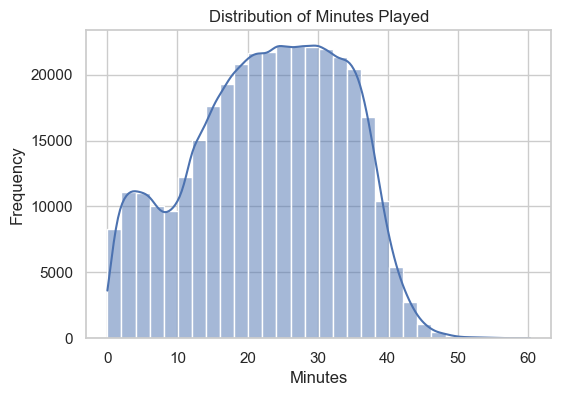

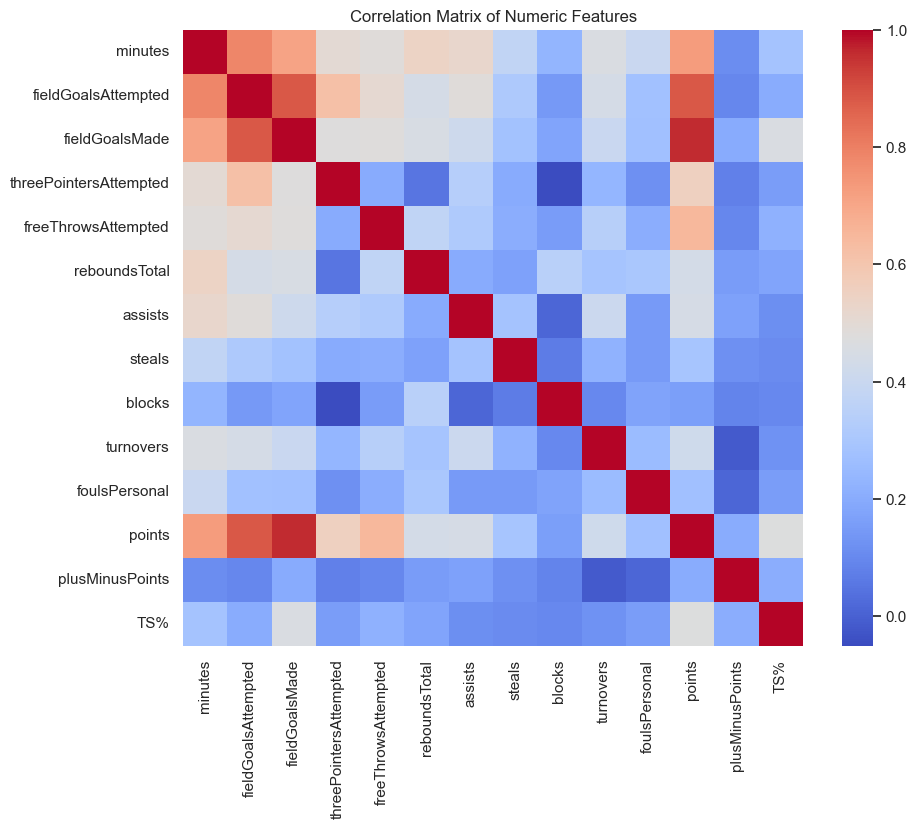

In [194]:
regular_season_data = add_true_shooting_percentage(regular_season_data)

# 1. Distribution of styles
style_counts = regular_season_data['style_label'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=style_counts.index, y=style_counts.values)
plt.title("Style Label Distribution (Row-Level)")
plt.xlabel("Style Label")
plt.ylabel("Count")
plt.show()

# 2. Minutes distribution
plt.figure(figsize=(6, 4))
sns.histplot(regular_season_data['minutes'], bins=30, kde=True)
plt.title("Distribution of Minutes Played")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

# 3. Correlation matrix of selected numeric features
numeric_cols = [
    'minutes', 'fieldGoalsAttempted', 'fieldGoalsMade', 'threePointersAttempted',
    'freeThrowsAttempted', 'reboundsTotal', 'assists', 'steals', 
    'blocks', 'turnovers', 'foulsPersonal', 'points', 'plusMinusPoints', 'TS%'
]
plt.figure(figsize=(10, 8))
corr_matrix = regular_season_data[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features")
plt.show()

### Data Aggregation and Player-Level Analysis

In this section, we aggregate the game-level statistics to player-level statistics using weighted averages based on minutes played. This gives us a more comprehensive view of each player's performance across multiple games.

The process involves:
1. Filling missing numeric values with 0 and unknown positions with 'Unknown'
2. Calculating weighted averages for all numeric statistics using minutes played as weights
3. Preserving categorical information like player name, position, and playing style
4. Grouping the data by player name to get one row per player

The weighted average approach ensures that games where a player had more playing time contribute more significantly to their overall statistics, providing a more accurate representation of their performance.


Number of data after grouping by player: 1689


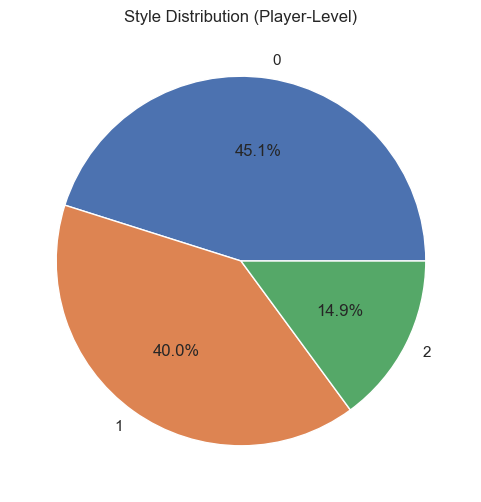

In [195]:
def fill_missing_numeric(df):
    numeric_cols = [
        'minutes',
        'fieldGoalsAttempted', 'fieldGoalsMade', 'fieldGoalsPercentage',
        'threePointersAttempted', 'threePointersMade', 'threePointersPercentage',
        'freeThrowsAttempted', 'freeThrowsMade', 'freeThrowsPercentage',
        'reboundsOffensive', 'reboundsDefensive', 'reboundsTotal',
        'assists', 'steals', 'blocks', 'turnovers', 'foulsPersonal',
        'points', 'plusMinusPoints', 'TS%'
    ]
    for col in numeric_cols:
        df[col] = df[col].fillna(0)
    df['position'] = df['position'].fillna('Unknown')
    return df, numeric_cols

def weighted_mean(series, weights):
    return 0 if weights.sum() == 0 else np.average(series, weights=weights)

def aggregate_player_stats(player_group, numeric_cols):
    minutes_played = player_group['minutes']
    
    # Calculate weighted averages for all numeric stats
    aggregated_stats = {
        col: weighted_mean(player_group[col], minutes_played) 
        for col in numeric_cols
    }
    
    # Add non-numeric fields
    aggregated_stats.update({
        'style_label': player_group['style_label'].iloc[0],
        'position': player_group['position'].mode()[0],
        'personName': player_group['personName'].iloc[0]
    })
    
    return pd.Series(aggregated_stats)

def group_by_player(df, numeric_cols):
    grouped_data = (df.groupby('personName')
                      .apply(lambda grp: aggregate_player_stats(grp, numeric_cols))
                      .reset_index(drop=True))
    
    print(f"Number of data after grouping by player: {len(grouped_data)}")
    
    # Pie chart of style distribution at player-level
    plt.figure(figsize=(6, 6))
    style_counts = grouped_data['style_label'].value_counts()
    plt.pie(style_counts, labels=style_counts.index, autopct='%1.1f%%')
    plt.title('Style Distribution (Player-Level)')
    plt.show()
    
    return grouped_data

# --- Execute aggregation ---
regular_season_data, numeric_cols = fill_missing_numeric(regular_season_data)
grouped_data = group_by_player(regular_season_data, numeric_cols)

### As you can see, there is a class imbalance in the data, especially in the 'Balanced' style. So we need to oversample the data.

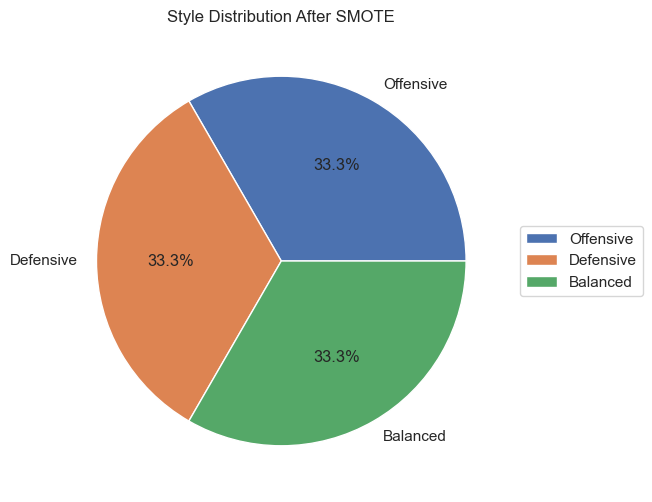

In [196]:
from imblearn.over_sampling import SMOTE

# Store non-numeric columns before SMOTE
non_numeric_cols = ['personName', 'position']
numeric_data = grouped_data.drop(columns=non_numeric_cols)
labels = grouped_data['style_label']

# Apply SMOTE only on numeric features
smote = SMOTE(random_state=42)
numeric_resampled, labels_resampled = smote.fit_resample(numeric_data, labels)

# Create new personName for synthetic samples
original_players = grouped_data['personName'].values
synthetic_players = [f"SYNTHETIC_PLAYER_{i}" for i in range(len(labels_resampled) - len(labels))]
all_players = np.concatenate([original_players, synthetic_players])

# Create new positions for synthetic samples
# Use random sampling from original positions for synthetic samples
original_positions = grouped_data['position'].values
synthetic_positions = np.random.choice(original_positions, size=len(synthetic_players))
all_positions = np.concatenate([original_positions, synthetic_positions])

# Reconstruct the DataFrame with both original and synthetic samples
grouped_data = pd.DataFrame(numeric_resampled, columns=numeric_data.columns)
grouped_data['personName'] = all_players
grouped_data['position'] = all_positions
grouped_data['style_label'] = labels_resampled

# show pie graph of style_label
plt.figure(figsize=(10, 6))
style_counts = grouped_data['style_label'].value_counts()
plt.pie(style_counts, labels=[k for k,v in style_mapping.items() if v in style_counts.index], 
        autopct='%1.1f%%')
plt.title('Style Distribution After SMOTE')
plt.legend([k for k,v in style_mapping.items() if v in style_counts.index], 
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()


### Feature Encoding and Splitting

In this section, we prepare our data for model training by:
1. One-hot encoding the player positions
2. One-hot encoding the target labels (playing styles)
3. Splitting the data into train/validation/test sets by unique players
4. Standardizing the numeric features using StandardScaler

In [197]:
def encode_and_split(df, numeric_cols, style_mapping):
    # One-hot encode positions
    position_encoded = pd.get_dummies(df['position'], prefix='pos')
    df = pd.concat([df, position_encoded], axis=1)

    # Final list of features
    position_features = list(position_encoded.columns)
    all_features = numeric_cols + position_features
    
    X_raw = df[all_features].values
    y_raw = df['style_label'].values.reshape(-1, 1)

    # One-hot encode the target
    encoder = OneHotEncoder(sparse_output=False)
    y_onehot = encoder.fit_transform(y_raw)

    # Train/Val/Test split by unique players
    players = df['personName'].unique().tolist()
    train_players, temp_players = train_test_split(players, test_size=0.3, random_state=42)
    val_players, test_players = train_test_split(temp_players, test_size=0.5, random_state=42)

    train_data = df[df['personName'].isin(train_players)]
    val_data   = df[df['personName'].isin(val_players)]
    test_data  = df[df['personName'].isin(test_players)]

    X_train_raw = train_data[all_features].values
    y_train_raw = train_data['style_label'].values.reshape(-1, 1)
    y_train_onehot = encoder.transform(y_train_raw)

    X_val_raw = val_data[all_features].values
    y_val_raw = val_data['style_label'].values.reshape(-1, 1)
    y_val_onehot = encoder.transform(y_val_raw)

    X_test_raw = test_data[all_features].values
    y_test_raw = test_data['style_label'].values.reshape(-1, 1)
    y_test_onehot = encoder.transform(y_test_raw)

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_val   = scaler.transform(X_val_raw)
    X_test  = scaler.transform(X_test_raw)

    return (X_train, y_train_onehot, y_train_raw, 
            X_val, y_val_onehot, y_val_raw, 
            X_test, y_test_onehot, y_test_raw, 
            encoder, all_features)

# --- Execute encoding and splitting ---
(X_train, y_train_onehot, y_train_raw, 
 X_val, y_val_onehot, y_val_raw, 
 X_test, y_test_onehot, y_test_raw, 
 encoder, all_features) = encode_and_split(grouped_data, numeric_cols, style_mapping)

### Class Weights and Other Helpers

The `compute_class_weights()` function calculates class weights to handle imbalanced datasets. For each class i, it computes:

In [198]:
def compute_class_weights(y):
    """Compute class weights as total_samples / (num_classes * class_counts[i])."""
    y_flat = y.flatten()
    class_counts = np.bincount(y_flat)
    total_samples = len(y_flat)
    num_classes = len(class_counts)
    class_weights_ = {}
    for i in range(num_classes):
        class_weights_[i] = total_samples / (num_classes * class_counts[i])
    return class_weights_
    
class_weights = compute_class_weights(y_train_raw)
class_weights

{0: np.float64(0.9696969696969697),
 1: np.float64(0.9950248756218906),
 2: np.float64(1.0376134889753568)}

### Neural Network Building Blocks

This section implements the core components of our neural network, including parameter initialization, activation functions, forward and backward propagation, loss computation, and optimization using Adam. The implementation follows standard deep learning practices with support for dropout regularization and L2 weight decay.

In [199]:
# =========================
# 8.1 Parameters Initialization
# =========================
def initialize_parameters(layer_sizes):
    """He-initialization for weight matrices, zeros for biases."""
    parameters = {}
    for l in range(1, len(layer_sizes)):
        parameters['W' + str(l)] = (
            np.random.randn(layer_sizes[l-1], layer_sizes[l]) 
            * np.sqrt(2. / layer_sizes[l-1])
        )
        parameters['b' + str(l)] = np.zeros((1, layer_sizes[l]))
    return parameters

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# =========================
# 8.2 Forward Pass
# =========================
def forward_pass(X, parameters, layer_sizes, keep_prob=1.0, training=True):
    caches = {}
    A = X
    L = len(layer_sizes) - 1

    for l in range(1, L):
        Z = np.dot(A, parameters['W' + str(l)]) + parameters['b' + str(l)]
        A = relu(Z)
        
        if training:
            D = np.random.rand(*A.shape) < keep_prob
            A = A * D
            A = A / keep_prob
            caches['D' + str(l)] = D

        caches['A' + str(l)] = A
        caches['Z' + str(l)] = Z

    ZL = np.dot(A, parameters['W' + str(L)]) + parameters['b' + str(L)]
    AL = softmax(ZL)
    caches['A' + str(L)] = AL
    caches['Z' + str(L)] = ZL

    return AL, caches

# =========================
# 8.3 Loss Function
# =========================
def compute_loss(y_true, y_pred, parameters, layer_sizes, lambd, sample_weights=None):
    m = y_true.shape[0]
    eps = 1e-8

    # Weighted cross-entropy
    if sample_weights is not None:
        ce_individual = -np.sum(y_true * np.log(y_pred + eps), axis=1)
        weighted_ce = np.sum(sample_weights * ce_individual) / (np.sum(sample_weights) + eps)
        data_loss = weighted_ce
    else:
        data_loss = -np.sum(y_true * np.log(y_pred + eps)) / m

    # L2 regularization
    reg_loss = 0
    L = len(layer_sizes) - 1
    for l in range(1, L + 1):
        reg_loss += np.sum(np.square(parameters['W' + str(l)]))
    reg_loss *= (lambd / (2 * m))

    return data_loss + reg_loss

# =========================
# 8.4 Backward Pass
# =========================
def backward_pass(X, y_true, parameters, caches, layer_sizes, lambd,
                  sample_weights=None, keep_prob=1.0):
    grads = {}
    m = X.shape[0]
    L = len(layer_sizes) - 1

    AL = caches['A' + str(L)]
    dZL = AL - y_true

    # Weight each sample by class weight if available
    if sample_weights is not None:
        dZL = dZL * sample_weights.reshape(-1, 1)

    A_prev = caches['A' + str(L-1)]
    grads['dW' + str(L)] = (
        np.dot(A_prev.T, dZL) / m
    ) + (lambd / m) * parameters['W' + str(L)]
    grads['db' + str(L)] = np.sum(dZL, axis=0, keepdims=True) / m

    dA_prev = np.dot(dZL, parameters['W' + str(L)].T)

    for l in reversed(range(1, L)):
        Z = caches['Z' + str(l)]
        dZ = dA_prev * relu_derivative(Z)

        if ('D' + str(l)) in caches:
            D = caches['D' + str(l)]
            dZ = dZ * D
            dZ = dZ / keep_prob

        A_prev = X if l == 1 else caches['A' + str(l-1)]

        grads['dW' + str(l)] = (
            np.dot(A_prev.T, dZ) / m
        ) + (lambd / m) * parameters['W' + str(l)]
        grads['db' + str(l)] = np.sum(dZ, axis=0, keepdims=True) / m

        dA_prev = np.dot(dZ, parameters['W' + str(l)].T)

    return grads

# =========================
# 8.5 Adam Optimizer
# =========================
def initialize_adam(parameters, layer_sizes):
    L = len(layer_sizes) - 1
    v = {}
    s = {}
    for l in range(1, L + 1):
        v['dW' + str(l)] = np.zeros_like(parameters['W' + str(l)])
        v['db' + str(l)] = np.zeros_like(parameters['b' + str(l)])
        s['dW' + str(l)] = np.zeros_like(parameters['W' + str(l)])
        s['db' + str(l)] = np.zeros_like(parameters['b' + str(l)])
    return v, s

def update_parameters_adam(parameters, grads, v, s, t, layer_sizes,
                           learning_rate, beta1, beta2, epsilon):
    L = len(layer_sizes) - 1
    v_corrected = {}
    s_corrected = {}

    for l in range(1, L + 1):
        # Moving average of the gradients
        v['dW' + str(l)] = beta1 * v['dW' + str(l)] + (1 - beta1) * grads['dW' + str(l)]
        v['db' + str(l)] = beta1 * v['db' + str(l)] + (1 - beta1) * grads['db' + str(l)]

        # Bias-corrected first moment
        v_corrected['dW' + str(l)] = v['dW' + str(l)] / (1 - beta1 ** t)
        v_corrected['db' + str(l)] = v['db' + str(l)] / (1 - beta1 ** t)

        # Moving average of the squared gradients
        s['dW' + str(l)] = beta2 * s['dW' + str(l)] + (1 - beta2) * (grads['dW' + str(l)] ** 2)
        s['db' + str(l)] = beta2 * s['db' + str(l)] + (1 - beta2) * (grads['db' + str(l)] ** 2)

        # Bias-corrected second moment
        s_corrected['dW' + str(l)] = s['dW' + str(l)] / (1 - beta2 ** t)
        s_corrected['db' + str(l)] = s['db' + str(l)] / (1 - beta2 ** t)

        # Update
        parameters['W' + str(l)] -= (learning_rate 
                                     * v_corrected['dW' + str(l)] 
                                     / (np.sqrt(s_corrected['dW' + str(l)]) + epsilon))
        parameters['b' + str(l)] -= (learning_rate 
                                     * v_corrected['db' + str(l)] 
                                     / (np.sqrt(s_corrected['db' + str(l)]) + epsilon))

    return parameters, v, s

# Training Loop and Evaluation

The training loop implements a neural network training process with several key features:

**Adam Optimization**: Uses the Adam optimizer with momentum (beta1) and RMSprop (beta2) parameters for efficient gradient descent

**Mini-batch Training**: Processes data in small batches to balance computational efficiency and training stability
   - Randomly shuffles training data each epoch
   - Processes batches of size 32 by default

**Regularization Techniques**:
   - L2 regularization (lambda parameter) to prevent overfitting
   - Dropout (30% by default) during training for better generalization
   - Class weights to handle imbalanced data

**Early Stopping**:
   - Monitors validation loss
   - Saves best model parameters
   - Stops training if validation loss doesn't improve for 15 epochs
   - Prevents overfitting by avoiding unnecessary training iterations


The evaluation function provides detailed model assessment including:
- Accuracy metrics
- Classification report with precision, recall, and F1-score per class

In [200]:
def train_neural_network(X_train, y_train_onehot, y_train_labels,
                         X_val, y_val_onehot, y_val_labels,
                         layer_sizes,
                         class_weights,
                         learning_rate=0.0005,
                         lambd=0.001,
                         num_epochs=100,
                         batch_size=32,
                         dropout_rate=0.3,
                         beta1=0.9,
                         beta2=0.999,
                         epsilon=1e-8,
                         patience=15):
    """
    Trains the neural network using Adam with early stopping.
    Returns the trained parameters.
    """
    # Initialize parameters
    parameters = initialize_parameters(layer_sizes)
    v, s = initialize_adam(parameters, layer_sizes)
    t = 0
    best_parameters = None
    best_val_loss = np.inf
    patience_counter = 0
    keep_prob = 1.0 - dropout_rate

    for epoch in range(num_epochs):
        permutation = np.random.permutation(X_train.shape[0])
        X_train_shuffled = X_train[permutation]
        y_train_shuffled = y_train_onehot[permutation]
        y_labels_shuffled = y_train_labels[permutation].flatten()

        # Mini-batch training
        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_train_shuffled[i:i+batch_size]
            y_batch = y_train_shuffled[i:i+batch_size]
            y_batch_labels = y_labels_shuffled[i:i+batch_size]

            # Forward pass (with dropout)
            AL, caches = forward_pass(X_batch, parameters, layer_sizes,
                                      keep_prob=keep_prob, training=True)

            # Weighted loss
            sample_w = np.array([class_weights[label] for label in y_batch_labels])
            loss = compute_loss(y_batch, AL, parameters, layer_sizes, lambd,
                                sample_weights=sample_w)

            # Backward pass
            grads = backward_pass(X_batch, y_batch, parameters, caches, layer_sizes, lambd,
                                  sample_weights=sample_w, keep_prob=keep_prob)

            # Adam update
            t += 1
            parameters, v, s = update_parameters_adam(parameters, grads, v, s, t,
                                                      layer_sizes, learning_rate,
                                                      beta1, beta2, epsilon)

        # Evaluate on full train and val (no dropout)
        AL_train, _ = forward_pass(X_train, parameters, layer_sizes, keep_prob=1.0, training=False)
        train_loss = compute_loss(y_train_onehot, AL_train, parameters, layer_sizes, lambd)

        AL_val, _ = forward_pass(X_val, parameters, layer_sizes, keep_prob=1.0, training=False)
        val_loss = compute_loss(y_val_onehot, AL_val, parameters, layer_sizes, lambd)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_parameters = {k: v.copy() for k, v in parameters.items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Restore best parameters
    return best_parameters

def evaluate_model(X, y_raw, parameters, layer_sizes, style_mapping, set_name="Test"):
    AL, _ = forward_pass(X, parameters, layer_sizes, keep_prob=1.0, training=False)
    y_pred = np.argmax(AL, axis=1)
    y_true = y_raw.flatten()
    acc = accuracy_score(y_true, y_pred)
    print(f"{set_name} Accuracy: {acc:.4f}")
    print(f"{set_name} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=style_mapping.keys()))


# Training & Final Evaluation

In [201]:
input_size = X_train.shape[1]
hidden_sizes = [128, 64, 32]
output_size = 3
layer_sizes = [input_size] + hidden_sizes + [output_size]

trained_parameters = train_neural_network(
    X_train, y_train_onehot, y_train_raw,
    X_val, y_val_onehot, y_val_raw,
    layer_sizes,
    class_weights,
    learning_rate=0.0005,
    lambd=0.001,
    num_epochs=100,
    batch_size=32,
    dropout_rate=0.3,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    patience=15
)

# Evaluation on Validation Set
AL_val, _ = forward_pass(X_val, trained_parameters, layer_sizes, keep_prob=1.0, training=False)
y_pred_val = np.argmax(AL_val, axis=1)
y_true_val = y_val_raw.flatten()
acc_val = accuracy_score(y_true_val, y_pred_val)
print(f"Validation Accuracy: {acc_val:.4f}")
print(f"Validation Classification Report:")
print(classification_report(y_true_val, y_pred_val, target_names=style_mapping.keys()))

# Evaluation on Test Set
AL_test, _ = forward_pass(X_test, trained_parameters, layer_sizes, keep_prob=1.0, training=False)
y_pred_test = np.argmax(AL_test, axis=1)
y_true_test = y_test_raw.flatten()
acc_test = accuracy_score(y_true_test, y_pred_test)
print(f"Test Accuracy: {acc_test:.4f}")
print(f"Test Classification Report:")
print(classification_report(y_true_test, y_pred_test, target_names=style_mapping.keys()))

Epoch 10/100, Train Loss: 0.7361, Val Loss: 0.7605
Epoch 20/100, Train Loss: 0.6643, Val Loss: 0.7186
Epoch 30/100, Train Loss: 0.6292, Val Loss: 0.7154
Epoch 40/100, Train Loss: 0.6010, Val Loss: 0.6998
Epoch 50/100, Train Loss: 0.5771, Val Loss: 0.7037
Early stopping at epoch 52
Validation Accuracy: 0.7201
Validation Classification Report:
              precision    recall  f1-score   support

   Offensive       0.67      0.76      0.71       106
   Defensive       0.74      0.71      0.73       118
    Balanced       0.75      0.69      0.72       119

    accuracy                           0.72       343
   macro avg       0.72      0.72      0.72       343
weighted avg       0.72      0.72      0.72       343

Test Accuracy: 0.7201
Test Classification Report:
              precision    recall  f1-score   support

   Offensive       0.74      0.71      0.72       106
   Defensive       0.70      0.73      0.71       108
    Balanced       0.73      0.72      0.72       129

    acc

### **Results Analysis & Discussion**

Our neural network model trained for 52 epochs and achieved good results:

- Training and validation loss both improved steadily
- Final accuracy: 72.01% on both validation and test sets
- Model performed equally well for all three playstyles (Offensive, Defensive, Balanced)
- No bias towards any particular class

The model successfully learned to identify different player playstyles and could be useful for analyzing player behavior.
